In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("../data/raw/sp500_stocks") 
files = sorted(DATA_DIR.glob("*.csv"))

len(files), files[0].name

(503, 'A.csv')

In [2]:
sample_fp = files[0]  # A.csv

df_sample = pd.read_csv(sample_fp)

print("Columns:")
print(df_sample.columns)

print("\nFirst 5 rows:")
df_sample.head()

Columns:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

First 5 rows:


,Date,Close,High,Low,Open,Volume
0,1999-11-18,26.347021,29.939798,23.951837,27.245214,62546380
1,1999-11-19,24.176392,25.748231,23.839568,25.710805,15234146
2,1999-11-22,26.347021,26.347021,23.989261,24.737756,6577870
3,1999-11-23,23.951841,26.122478,23.951841,25.448832,5975611
4,1999-11-24,24.588074,25.112021,23.951852,24.026702,4843231


In [3]:
df = df_sample.copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df = df[["Date", "Close"]].rename(columns={"Close": "price"})

df.head(), df.tail()

(        Date      price
 0 1999-11-18  26.347021
 1 1999-11-19  24.176392
 2 1999-11-22  26.347021
 3 1999-11-23  23.951841
 4 1999-11-24  24.588074,
            Date       price
 6538 2025-11-17  144.520004
 6539 2025-11-18  143.839996
 6540 2025-11-19  144.399994
 6541 2025-11-20  145.059998
 6542 2025-11-21  151.250000)

In [4]:
start_dates = {}
end_dates = {}

for fp in files:
    df = pd.read_csv(fp)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    
    ticker = fp.stem
    start_dates[ticker] = df["Date"].min()
    end_dates[ticker] = df["Date"].max()

start_series = pd.Series(start_dates)
end_series = pd.Series(end_dates)

print("Earliest start among all tickers:", start_series.min())
print("Latest end among all tickers:", end_series.max())

print("\nStart date distribution:")
start_series.sort_values().head(10)

Earliest start among all tickers: 1962-01-02 00:00:00
Latest end among all tickers: 2025-11-21 00:00:00

Start date distribution:


DIS   1962-01-02
MSI   1962-01-02
CNP   1962-01-02
MRK   1962-01-02
CVX   1962-01-02
BA    1962-01-02
PG    1962-01-02
KR    1962-01-02
MO    1962-01-02
MMM   1962-01-02
dtype: datetime64[ns]

In [ ]:
latest_start = start_series.max()
earliest_end = end_series.min()
latest_end = end_series.max()

print("Latest start (max start):", latest_start)
print("Earliest end (min end):", earliest_end)
print("Latest end (max end):", latest_end)

ended_early = end_series[end_series < latest_end].sort_values()
print("\nHow many tickers end before latest end?", len(ended_early))
ended_early.head(20)

Latest start (max start): 2025-10-20 00:00:00
Earliest end (min end): 2025-11-21 00:00:00
Latest end (max end): 2025-11-21 00:00:00

How many tickers end before latest end? 0


Series([], dtype: datetime64[ns])

In [6]:
latest_start = start_series.max()

tickers_with_latest_start = start_series[start_series == latest_start]
tickers_with_latest_start

SOLS   2025-10-20
dtype: datetime64[ns]

In [7]:
fp_sols = DATA_DIR / "SOLS.csv"

df_sols = pd.read_csv(fp_sols)
df_sols["Date"] = pd.to_datetime(df_sols["Date"])
df_sols = df_sols.sort_values("Date")

print("Number of rows:", len(df_sols))
print("Start:", df_sols["Date"].min())
print("End:", df_sols["Date"].max())

df_sols.head(), df_sols.tail()

Number of rows: 25
Start: 2025-10-20 00:00:00
End: 2025-11-21 00:00:00


(        Date      Close       High        Low       Open  Volume
 0 2025-10-20  48.400002  61.000000  48.099998  52.750000  275800
 1 2025-10-21  49.799999  51.119999  49.509998  50.049999  202700
 2 2025-10-22  47.400002  50.009998  47.049999  50.009998  323900
 3 2025-10-23  46.000000  49.160000  45.650002  49.160000  141400
 4 2025-10-24  45.750000  47.599998  44.049999  46.310001  648900,
          Date      Close       High        Low       Open   Volume
 20 2025-11-17  41.580002  43.799999  41.029999  43.119999  4173600
 21 2025-11-18  41.430000  42.540001  40.430000  41.040001  3535600
 22 2025-11-19  42.720001  43.750000  41.320000  41.580002  4270700
 23 2025-11-20  43.250000  46.669998  42.770000  45.180000  4882400
 24 2025-11-21  44.439999  45.459999  43.299999  43.490002  3811100)

In [ ]:
obs_count = {}

for fp in files:
    df = pd.read_csv(fp)
    obs_count[fp.stem] = len(df)

obs_series = pd.Series(obs_count)

estimation_window = 756

eligible = obs_series[obs_series >= estimation_window]

print("Total tickers:", len(obs_series))
print("Eligible tickers (>= 756 obs):", len(eligible))
print("Dropped tickers:", len(obs_series) - len(eligible))

Total tickers: 503
Eligible tickers (>= 756 obs): 497
Dropped tickers: 6


In [9]:
prices = []

for fp in files:
    ticker = fp.stem
    if ticker in eligible.index:
        df = pd.read_csv(fp)
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")
        df = df[["Date", "Close"]].rename(columns={"Close": ticker})
        df = df.set_index("Date")
        prices.append(df)

prices_wide = pd.concat(prices, axis=1).sort_index()

prices_wide.shape

(16082, 497)

count    16082.000000
mean       270.079406
std        166.552880
min         24.000000
25%         89.000000
50%        279.000000
75%        425.000000
max        497.000000
dtype: float64


<Axes: xlabel='Date'>

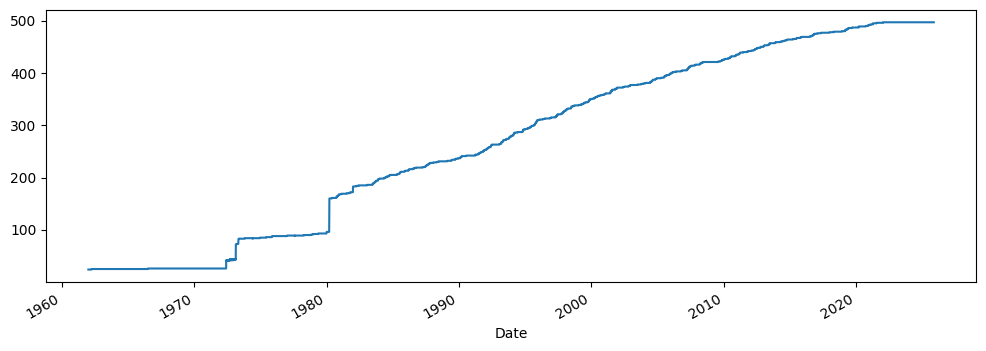

In [10]:
active_per_day = prices_wide.notna().sum(axis=1)

print(active_per_day.describe())

active_per_day.plot(figsize=(12,4))

count    5257.000000
mean      458.265931
std        33.606660
min       390.000000
25%       427.000000
50%       465.000000
75%       489.000000
max       497.000000
dtype: float64


<Axes: xlabel='Date'>

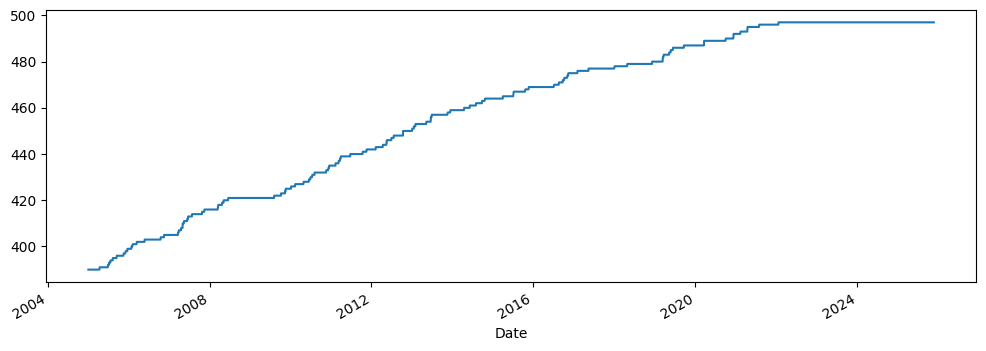

In [ ]:
active_2005 = active_per_day[active_per_day.index >= "2005-01-01"]

print(active_2005.describe())

active_2005.plot(figsize=(12,4))

In [12]:
prices_2005 = prices_wide[prices_wide.index >= "2005-01-01"]

coverage = prices_2005.notna().mean()
final_universe = coverage[coverage >= 0.95].index

len(final_universe)

399

In [13]:
prices_u = prices_2005[final_universe].copy()

returns_u = np.log(prices_u).diff()

missing_days = returns_u.isna().any(axis=1).sum()
total_days = len(returns_u)

print("Days with any missing:", missing_days, "out of", total_days,
      f"({missing_days/total_days:.2%})")

returns_u_clean = returns_u.dropna(how="any")

print("After dropna, days:", len(returns_u_clean))

Days with any missing: 246 out of 5257 (4.68%)
After dropna, days: 5011


In [ ]:
missing_dates = returns_u[returns_u.isna().any(axis=1)].index

missing_dates[:10], missing_dates[-10:]

(DatetimeIndex(['2005-01-03', '2005-01-04', '2005-01-05', '2005-01-06',
                '2005-01-07', '2005-01-10', '2005-01-11', '2005-01-12',
                '2005-01-13', '2005-01-14'],
               dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2005-12-08', '2005-12-09', '2005-12-12', '2005-12-13',
                '2005-12-14', '2005-12-15', '2005-12-16', '2005-12-19',
                '2005-12-20', '2005-12-21'],
               dtype='datetime64[ns]', name='Date', freq=None))

In [ ]:
prices_u = prices_2005[final_universe].copy()
returns_u = np.log(prices_u).diff()

missing_by_ticker = returns_u.isna().mean().sort_values(ascending=False)

missing_by_ticker.head(20)

LYV     0.046795
PSKY    0.044512
ICE     0.042229
AMP     0.033860
CF      0.029294
EXPE    0.026441
WBD     0.024729
BLDR    0.023397
DXCM    0.013506
NDAQ    0.000190
MTD     0.000190
NVR     0.000190
NVDA    0.000190
NUE     0.000190
MTCH    0.000190
NTRS    0.000190
NTAP    0.000190
NSC     0.000190
NRG     0.000190
MU      0.000190
dtype: float64

In [ ]:
def missing_days_ratio(ret_df):
    md = ret_df.isna().any(axis=1).sum()
    return md, len(ret_df), md/len(ret_df)

md0, tot0, r0 = missing_days_ratio(returns_u)
print("Initial:", md0, "/", tot0, f"({r0:.2%})")

for k in [5, 8, 10]:
    drop_tickers = missing_by_ticker.head(k).index
    ret_k = returns_u.drop(columns=drop_tickers)
    md, tot, r = missing_days_ratio(ret_k)
    print(f"Drop worst {k}: {md}/{tot} ({r:.2%}), universe={ret_k.shape[1]}")

Initial: 246 / 5257 (4.68%)
Drop worst 5: 139/5257 (2.64%), universe=394
Drop worst 8: 71/5257 (1.35%), universe=391
Drop worst 10: 1/5257 (0.02%), universe=389


In [ ]:
drop_tickers = missing_by_ticker.head(10).index
returns_final = returns_u.drop(columns=drop_tickers)

returns_final = returns_final.dropna(how="any")

print("Final shape:", returns_final.shape)
print("Universe size:", returns_final.shape[1])
print("Total days:", returns_final.shape[0])

Final shape: (5256, 389)
Universe size: 389
Total days: 5256


In [ ]:
from pathlib import Path
import json

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

returns_final.to_csv(out_dir / "returns_final.csv")

universe_df = pd.DataFrame({
    "ticker": returns_final.columns
})
universe_df.to_csv(out_dir / "universe.csv", index=False)

notes = {
    "start_date": "2005-01-01",
    "return_type": "log",
    "estimation_window_days": 756,
    "universe_size": int(returns_final.shape[1]),
    "n_days": int(returns_final.shape[0]),
    "dropped_tickers_top_missing": list(drop_tickers),
    "price_field_used": "Close",
    "adj_close_available": False
}

with open(out_dir / "data_notes.json", "w") as f:
    json.dump(notes, f, indent=2)

print("Saved:", out_dir / "returns_final.csv")
print("Saved:", out_dir / "universe.csv")
print("Saved:", out_dir / "data_notes.json")

NameError: name 'returns_final' is not defined